# Temperatura e carga energética no Sudeste/Centro-Oeste

Trabalho final de Álgebra Linear.

A pergunta é direta: quando faz mais calor, o sistema elétrico do Sudeste/Centro-Oeste consome mais energia? Faz sentido intuitivamente — ar-condicionado, ventilador e geladeira trabalham mais quando esquenta. Pra investigar isso a gente cruzou duas bases reais — temperatura média diária das capitais do Sudeste e do Centro-Oeste (NASA POWER) e a carga energética diária do subsistema SE/CO (ONS), as duas cobrindo 2025 — e ajustou uma regressão linear simples.

Não é um modelo pra prever consumo de verdade. A carga depende de um monte de coisa além do clima (atividade industrial, dia da semana, feriado, chuva). A ideia é só ver se a relação aparece nos dados e exercitar a parte de Álgebra Linear: escrever o problema como $\mathbf{X}\mathbf{w} \approx \mathbf{y}$ e resolver por mínimos quadrados.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Carregamento das bases

**Temperatura.** Série de temperatura média diária, em °C, calculada como média entre 8 capitais — 4 do Sudeste (SP, RJ, BH, Vitória) e 4 do Centro-Oeste (Brasília, Goiânia, Cuiabá, Campo Grande). Os dados vieram da NASA POWER (variável T2M, temperatura a 2 m da superfície) e foram baixados/agregados pelo notebook `dados.ipynb`.

**Carga de energia.** Dado público da ONS com a carga energética média diária (em MWmed). O arquivo original vem com os 4 subsistemas do SIN (N, NE, S, SE) empilhados; a gente já filtrou em separado uma versão só com o subsistema SE (Sudeste/Centro-Oeste), que é a usada aqui. A escolha das capitais da temperatura foi pra cobrir aproximadamente a mesma área geográfica desse subsistema.

In [22]:
temp = pd.read_csv('dataset/temperatura_diaria_sudeste_centro_oeste.csv', parse_dates=['data'])
temp.head()

,data,temperatura_media
0,2025-01-01,24.77
1,2025-01-02,24.60
2,2025-01-03,24.97
3,2025-01-04,24.80
4,2025-01-05,24.62


In [23]:
# Versao limpa do CSV da ONS: so as linhas do subsistema SE (Sudeste/Centro-Oeste).
carga = pd.read_csv('dataset/carga_energia_sudeste_2025.csv', sep=';', parse_dates=['din_instante'])
carga.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,SE,Sudeste/Centro-Oeste,2025-01-01,35903.900458
1,SE,Sudeste/Centro-Oeste,2025-01-02,42515.234500
2,SE,Sudeste/Centro-Oeste,2025-01-03,44511.483125
3,SE,Sudeste/Centro-Oeste,2025-01-04,42866.861792
4,SE,Sudeste/Centro-Oeste,2025-01-05,39566.966250


## 3. Tratamento dos dados

Pra montar a regressão a gente precisa de uma única tabela com `data | temperatura | carga` no mesmo grão (diário) e na mesma janela.

- Na carga, renomeamos as colunas pra algo mais curto (`din_instante` → `data`, `val_cargaenergiamwmed` → `carga_mwmed`).
- Na temperatura, alguns dias do fim da série estão em branco — descartamos com `dropna`.
- Por fim, um `merge` inner por data deixa só os dias que existem nas duas bases. Como a carga da ONS vai até dez/2025, a interseção fica no ano de 2025 cheio.

In [24]:
carga_se = (
    carga
    .rename(columns={'din_instante': 'data', 'val_cargaenergiamwmed': 'carga_mwmed'})
    [['data', 'carga_mwmed']]
)

temp_ok = temp.dropna(subset=['temperatura_media'])

df = pd.merge(temp_ok, carga_se, on='data', how='inner').sort_values('data').reset_index(drop=True)
print(f'{len(df)} dias apos o merge')
df.head()

365 dias apos o merge


,data,temperatura_media,carga_mwmed
0,2025-01-01,24.77,35903.900458
1,2025-01-02,24.60,42515.234500
2,2025-01-03,24.97,44511.483125
3,2025-01-04,24.80,42866.861792
4,2025-01-05,24.62,39566.966250


## 4. Visualização inicial

Antes de ajustar qualquer reta, vale dar uma olhada na cara dos dados — como cada série se comporta no tempo e como elas se relacionam num scatter.

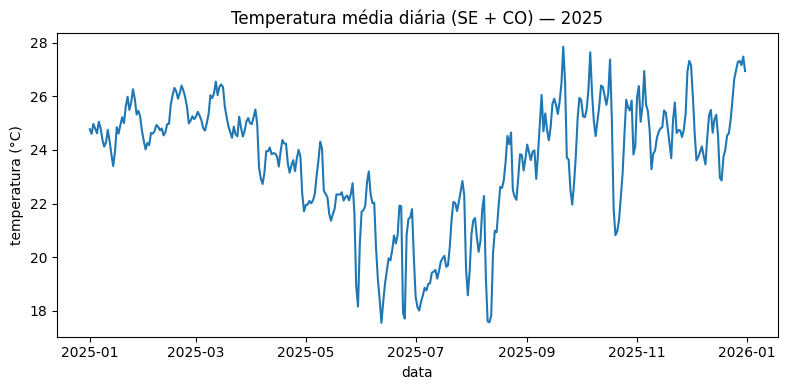

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(df['data'], df['temperatura_media'])
plt.title('Temperatura média diária (SE + CO) — 2025')
plt.xlabel('data')
plt.ylabel('temperatura (°C)')
plt.tight_layout()
plt.show()

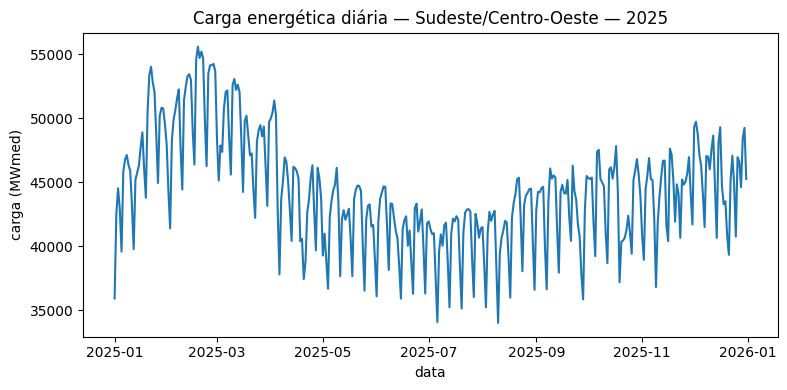

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(df['data'], df['carga_mwmed'])
plt.title('Carga energética diária — Sudeste/Centro-Oeste — 2025')
plt.xlabel('data')
plt.ylabel('carga (MWmed)')
plt.tight_layout()
plt.show()

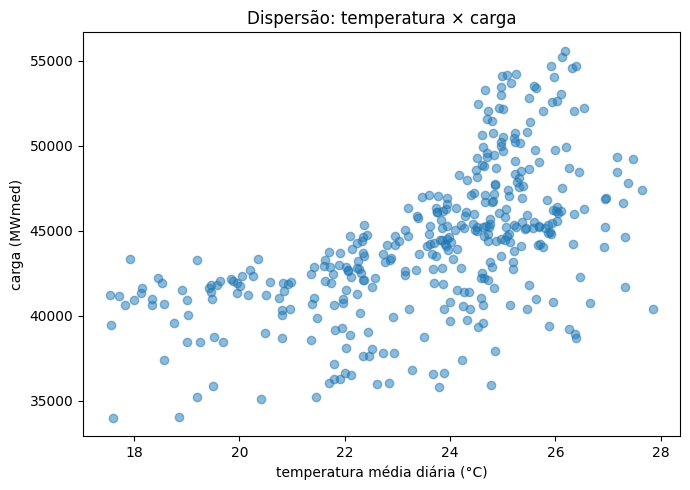

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(df['temperatura_media'], df['carga_mwmed'], alpha=0.5)
plt.title('Dispersão: temperatura × carga')
plt.xlabel('temperatura média diária (°C)')
plt.ylabel('carga (MWmed)')
plt.tight_layout()
plt.show()

## 5. Modelagem matemática

Assumimos uma relação linear entre temperatura e carga:

$$ y = w_0 + w_1\, x $$

No nosso caso $x$ é a temperatura média diária (°C) e $y$ é a carga energética do subsistema SE/CO (MWmed). O $w_1$ diz quantos MWmed a carga varia para cada grau a mais; o $w_0$ é o intercepto.

Como temos 365 observações (um dia por linha), dá pra escrever isso de forma matricial empilhando as equações:

$$
\underbrace{\begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_{365} \end{pmatrix}}_{\mathbf{X}}
\underbrace{\begin{pmatrix} w_0 \\ w_1 \end{pmatrix}}_{\mathbf{w}}
\;\approx\;
\underbrace{\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_{365} \end{pmatrix}}_{\mathbf{y}}
$$

Ou seja, $\mathbf{X}\mathbf{w} \approx \mathbf{y}$. O sistema não tem solução exata (os pontos não caem todos numa reta), então procuramos o $\mathbf{w}$ que minimiza $\|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2$. Esse é o problema de mínimos quadrados, e é o que a função `np.linalg.lstsq` resolve.

## 6. Regressão linear

Aplicando isso aos nossos dados: a gente monta $\mathbf{X}$ com uma coluna de 1s (pro intercepto) e outra coluna com as temperaturas, e passa pra `np.linalg.lstsq`.

In [28]:
x = df['temperatura_media'].values
y = df['carga_mwmed'].values

X = np.column_stack([np.ones(len(x)), x])
w, *_ = np.linalg.lstsq(X, y, rcond=None)
w0, w1 = w

print(f'Intercepto (w0): {w0:.2f}')
print(f'Coef. angular (w1): {w1:.2f}')
print(f'Equacao ajustada: carga = {w0:.2f} + {w1:.2f} * temperatura')

Intercepto (w0): 18445.96
Coef. angular (w1): 1092.74
Equacao ajustada: carga = 18445.96 + 1092.74 * temperatura


## 7. Resultado gráfico

Agora o scatter de novo, com a reta ajustada por cima.

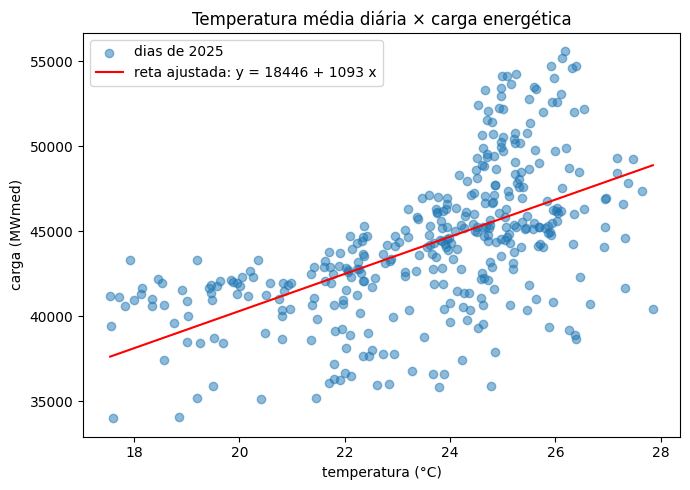

In [29]:
xs = np.linspace(x.min(), x.max(), 100)
ys = w0 + w1 * xs

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.5, label='dias de 2025')
plt.plot(xs, ys, color='red', label=f'reta ajustada: y = {w0:.0f} + {w1:.0f} x')
plt.title('Temperatura média diária × carga energética')
plt.xlabel('temperatura (°C)')
plt.ylabel('carga (MWmed)')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
y_pred = X @ w
r2 = 1 - ((y - y_pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
print(f'R2 = {r2:.3f}')

R2 = 0.329


## 8. Interpretação dos resultados

O coeficiente angular ficou positivo, na direção esperada: cada +1 °C na temperatura média diária está associado a um aumento de cerca de mil MWmed na carga do subsistema SE/CO. Faz sentido — calor empurra ar-condicionado, ventilador e geladeira, e isso aparece na demanda agregada.

O R² mostra o quanto da variação da carga a temperatura sozinha consegue explicar. A dispersão no scatter já dava o tom: os pontos seguem a tendência mas com uma nuvem grossa em volta, então a reta capta a direção média, não o comportamento de cada dia.

## 9. Limitações

- **A carga depende de muito mais que temperatura.** Atividade industrial, dia da semana, feriado, chuva (que muda o despacho hidrelétrico e o padrão de consumo), eventos pontuais — nada disso entrou no modelo.
- **Sazonalidade não foi tratada.** Tem um padrão anual claro (verão vs. inverno) que se confunde com o efeito da temperatura, e a gente não separa um do outro.
- **Janela de um ano.** Os dados de carga que usamos cobrem só 2025. Com mais anos dava pra ver se a relação se mantém ou muda.
- **A média entre as 8 capitais é grosseira.** Cada cidade tem peso igual na média de temperatura, mas elas não pesam o mesmo no consumo (São Paulo concentra muito mais carga que Cuiabá, por exemplo). Uma média ponderada por população ou consumo seria mais fiel.
- **Regressão linear é uma aproximação.** Pode existir efeito não-linear (a carga não sobe na mesma taxa em qualquer faixa de temperatura), mas com regressão linear simples a gente não consegue ver isso.

## 10. Conclusão

A relação aparece nos dados e o sinal é o esperado: temperatura mais alta vem acompanhada de carga maior no subsistema SE/CO. O R² confirma que a tendência existe, mas que ela divide o palco com muitos outros fatores — o que era esperado pra um problema desse tipo.